In [31]:
!pip install tensorflow numpy matplotlib scikit-learn

  Using cached scikit_learn-1.6.1-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached joblib-1.5.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.6.1-cp312-cp312-win_amd64.whl (11.1 MB)
Using cached joblib-1.5.0-py3-none-any.whl (307 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# Cell 1: Installation
!pip install -q torch torchvision matplotlib numpy pandas opencv-python seaborn tqdm

import os
import glob



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import cv2
import random

# Preparing The Data

In [20]:
# Cell 2: Find and display permutation datasets
permutation_dirs = glob.glob('datasets/Permutation*')
print(f"Found {len(permutation_dirs)} Permutation datasets:")

for perm_dir in permutation_dirs:
    print(f"  - {perm_dir}")
    # Check structure of each dataset
    for subset in ['train', 'test', 'valid']:
        subset_path = os.path.join(perm_dir, subset)
        if os.path.exists(subset_path):
            image_files = glob.glob(os.path.join(subset_path, '*.jpg')) + \
                         glob.glob(os.path.join(subset_path, '*.png'))
            label_files = glob.glob(os.path.join(subset_path, '*.txt'))
            print(f"      {subset}: {len(image_files)} images, {len(label_files)} labels")

Found 6 Permutation datasets:
  - datasets\Permutation1
      train: 1367 images, 0 labels
      test: 197 images, 0 labels
      valid: 390 images, 0 labels
  - datasets\Permutation2
      train: 1367 images, 0 labels
      test: 197 images, 0 labels
      valid: 390 images, 0 labels
  - datasets\Permutation3
      train: 1367 images, 0 labels
      test: 197 images, 0 labels
      valid: 390 images, 0 labels
  - datasets\Permutation4
      train: 1367 images, 0 labels
      test: 197 images, 0 labels
      valid: 390 images, 0 labels
  - datasets\Permutation5
      train: 1367 images, 0 labels
      test: 197 images, 0 labels
      valid: 390 images, 0 labels
  - datasets\Permutation6
      train: 1367 images, 0 labels
      test: 197 images, 0 labels
      valid: 390 images, 0 labels


In [21]:
# Cell 3: Create YAML config files for YOLOv5
def create_dataset_yaml(dataset_dir):
    dataset_name = os.path.basename(dataset_dir)
    yaml_content = f"""
# {dataset_name} Dataset YAML
path: {os.path.abspath(dataset_dir)}  # dataset root dir
train: train/  # train images
val: valid/  # validation images
test: test/  # test images

# Classes
names:
  0: object
"""
    
    yaml_path = f"{dataset_name}.yaml"
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)
    
    print(f"Created YAML config file: {yaml_path}")
    return yaml_path

# Create YAML for each dataset
yaml_files = [create_dataset_yaml(perm_dir) for perm_dir in permutation_dirs]

Created YAML config file: Permutation1.yaml
Created YAML config file: Permutation2.yaml
Created YAML config file: Permutation3.yaml
Created YAML config file: Permutation4.yaml
Created YAML config file: Permutation5.yaml
Created YAML config file: Permutation6.yaml


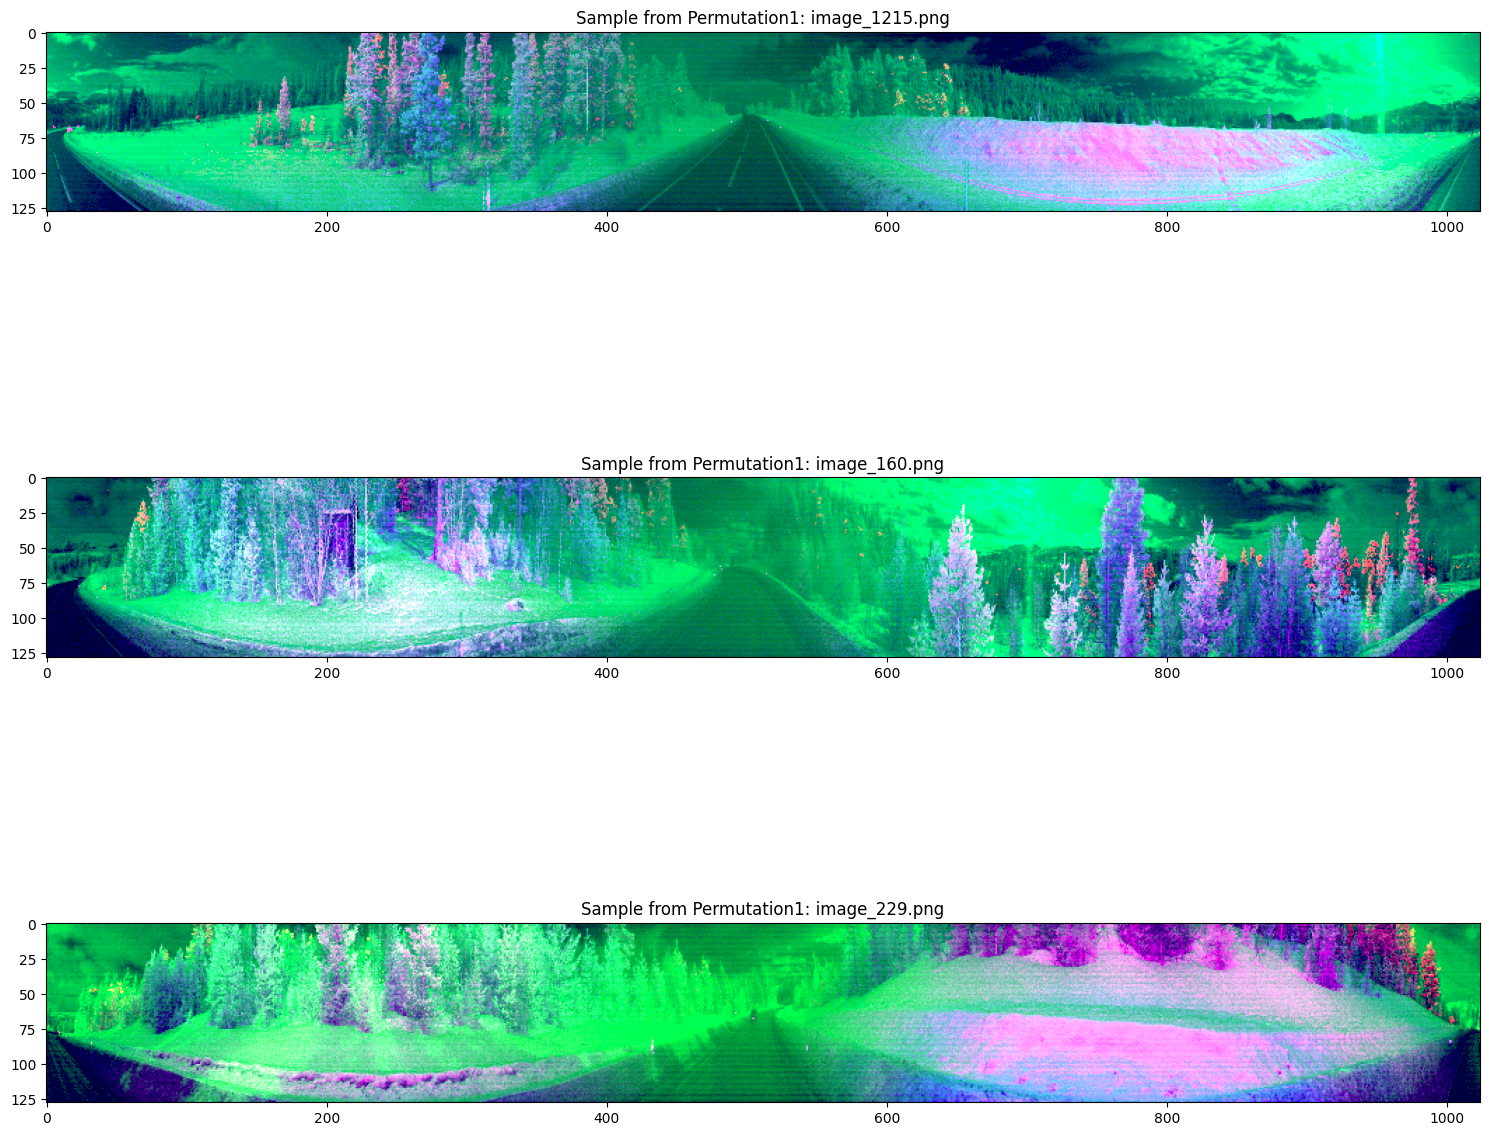

In [23]:
def display_sample_images(dataset_dir, num_samples=3):
    train_dir = os.path.join(dataset_dir, 'train')
    image_files = glob.glob(os.path.join(train_dir, '*.jpg')) + \
                  glob.glob(os.path.join(train_dir, '*.png'))
    
    if not image_files:
        print(f"No image files found in {train_dir}")
        return
    
    samples = random.sample(image_files, min(num_samples, len(image_files)))
    
    plt.figure(figsize=(15, 5*len(samples)))
    for i, img_path in enumerate(samples):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Get corresponding label file path
        label_path = img_path.replace('.jpg', '.txt').replace('.png', '.txt')
        if os.path.exists(label_path):
            # Read YOLO format labels
            with open(label_path, 'r') as f:
                lines = f.readlines()
            
            # Draw bounding boxes
            h, w, _ = img.shape
            for line in lines:
                parts = line.strip().split()
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:5])
                
                # Convert from YOLO format to pixel coordinates
                x1 = int((x_center - width/2) * w)
                y1 = int((y_center - height/2) * h)
                x2 = int((x_center + width/2) * w)
                y2 = int((y_center + height/2) * h)
                
                # Draw rectangle and class id
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, f"Class {class_id}", (x1, y1-10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        
        plt.subplot(len(samples), 1, i+1)
        plt.imshow(img)
        plt.title(f"Sample from {os.path.basename(dataset_dir)}: {os.path.basename(img_path)}")
    plt.tight_layout()
    plt.show()

# Display samples from a specific permutation dataset (change as needed)
if permutation_dirs:
    display_sample_images(permutation_dirs[0])

In [24]:
# Performance optimization - use buffered prefetching to yield data from disk
AUTOTUNE = tf.data.AUTOTUNE

def optimize_dataset(ds):
    if ds is None:
        return None
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

In [49]:
img_height,img_width=180,180
batch_size=32
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [50]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [51]:
class_names = train_ds.class_names
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


# Training The Model


In [28]:
# Cell 5: Proper imports and ResNet50 model creation
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Create Sequential model
resnet_model = Sequential()

# Load pretrained ResNet50 with your specific parameters
pretrained_model = ResNet50(
include_top=False,
input_shape=(128, 1028, 3),
pooling='avg',
weights='imagenet'
)

# Freeze the pretrained layers
for layer in pretrained_model.layers:
        layer.trainable = False

# Add pretrained model and additional layers
resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation='relu'))
resnet_model.add(Dense(1, activation='softmax'))

# Compile the model
resnet_model.compile(
optimizer=Adam(learning_rate=0.001),
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)
    


In [29]:
resnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,637,313 (93.98 MB)

 Trainable params: 1,049,601 (4.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet50 (Functional)        (None, 2048)              23587712  
_________________________________________________________________
flatten (Flatten)            (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 512)               1049088   
_________________________________________________________________
dense_1 (Dense)              (None, 5)                 2565      
Total params: 24,639,365
Trainable params: 1,051,653
Non-trainable params: 23,587,712
_________________________________________________________________


In [ ]:
epochs=3
history = resnet_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
92/92 [==============================] - 418s 5s/step - loss: 0.7422 - accuracy: 0.7715 - val_loss: 0.4269 - val_accuracy: 0.8488
Epoch 2/10
92/92 [==============================] - 396s 4s/step - loss: 0.2997 - accuracy: 0.8879 - val_loss: 0.3935 - val_accuracy: 0.8488
Epoch 3/10
92/92 [==============================] - 387s 4s/step - loss: 0.1788 - accuracy: 0.9380 - val_loss: 0.3644 - val_accuracy: 0.8638
Epoch 4/10
92/92 [==============================] - 391s 4s/step - loss: 0.1041 - accuracy: 0.9659 - val_loss: 0.4643 - val_accuracy: 0.8392
Epoch 5/10
92/92 [==============================] - 386s 4s/step - loss: 0.0598 - accuracy: 0.9843 - val_loss: 0.3616 - val_accuracy: 0.8774
Epoch 6/10
92/92 [==============================] - 387s 4s/step - loss: 0.0279 - accuracy: 0.9976 - val_loss: 0.3967 - val_accuracy: 0.8787
Epoch 7/10
92/92 [==============================] - 386s 4s/step - loss: 0.0143 - accuracy: 0.9993 - val_loss: 0.4017 - val_accuracy: 0.8937
Epoch 8/10
92

In [36]:

# Set parameters for dataset and model
selected_permutation = "Permutation1"  # CHANGE THIS TO YOUR DESIRED PERMUTATION
img_height = 128
img_width = 1024
batch_size = 16
epochs = 10  # ADJUST NUMBER OF EPOCHS AS NEEDED

# Build path to dataset
permutation_path = os.path.join(os.getcwd(), "datasets", selected_permutation)
if not os.path.exists(permutation_path):
    # Try searching for any permutation dataset
    permutation_dirs = glob.glob(os.path.join(os.getcwd(), 'datasets', 'Permutation*'))
    print('Available permutation directories:', permutation_dirs)
    if permutation_dirs:
        permutation_path = "datasets\\Permutation1\\train"
        selected_permutation = os.path.basename(permutation_path)
        print(f"Selected permutation not found. Using {selected_permutation} instead.")
    else:
        raise ValueError("No permutation datasets found!")

print(f"Using dataset: {permutation_path}")

# Check and load train dataset
train_dir = os.path.join(permutation_path, 'train')
if not os.path.exists(train_dir):
    raise ValueError(f"Train directory not found at {train_dir}")

print(f"Loading training data from {train_dir}...")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    seed=123
)

# Check and load validation dataset
valid_dir = os.path.join(permutation_path, 'valid')
if os.path.exists(valid_dir):
    print(f"Loading validation data from {valid_dir}...")
    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        valid_dir,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        seed=123
    )
else:
    print("Validation directory not found, using 20% of training data")
    val_size = int(0.2 * len(train_ds))
    train_ds = train_ds.shuffle(1000, seed=123)
    val_ds = train_ds.take(val_size)
    train_ds = train_ds.skip(val_size)

# Check and load test dataset
test_dir = os.path.join(permutation_path, 'test/')
has_test_data = os.path.exists(test_dir)
if has_test_data:
    print(f"Loading test data from {test_dir}...")
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        image_size=(img_height, img_width),
        batch_size=batch_size,
        seed=123
    )
else:
    print("⚠️ WARNING: Test directory not found! No final evaluation will be performed.")

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
if has_test_data:
    test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Get class info
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Found {num_classes} classes: {class_names}")

# Create model
print("Building ResNet50 model...")
resnet_model = Sequential()

# Load pretrained ResNet50
pretrained_model = ResNet50(
    include_top=False,
    input_shape=(img_height, img_width, 3),
    pooling='avg',
    weights='imagenet'
)

# Freeze the pretrained layers
for layer in pretrained_model.layers:
    layer.trainable = False

# Add layers to the model
resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation='relu'))
resnet_model.add(Dense(num_classes, activation='softmax'))

# Compile the model
resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
resnet_model.summary()

# Train the model
print(f"Training model on {selected_permutation} for {epochs} epochs...")
history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)


Using dataset: c:\Users\x1 yoga\Documents\RA_5m_5L_6m_6L_7m_8m_9m_10m_11m\datasets\Permutation1
Loading training data from c:\Users\x1 yoga\Documents\RA_5m_5L_6m_6L_7m_8m_9m_10m_11m\datasets\Permutation1\train...
Found 0 files belonging to 0 classes.


ValueError: No images found in directory c:\Users\x1 yoga\Documents\RA_5m_5L_6m_6L_7m_8m_9m_10m_11m\datasets\Permutation1\train. Allowed formats: ('.bmp', '.gif', '.jpeg', '.jpg', '.png')

In [ ]:

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# STEP 3: EVALUATE ON TEST SET - THIS IS THE IMPORTANT PART
print("\n" + "="*50)
print("FINAL EVALUATION ON TEST SET")
print("="*50)

if has_test_data:
    print("Evaluating model performance on separate test dataset...")
    test_loss, test_acc = resnet_model.evaluate(test_ds)
    print(f"📊 Test accuracy: {test_acc:.4f}")
    print(f"📉 Test loss: {test_loss:.4f}")
    
    # Show test predictions
    print("\nVisualizing predictions on test data...")
    plt.figure(figsize=(10, 10))
    
    test_images = []
    test_labels = []
    
    # Get a batch of test images
    for images, labels in test_ds.take(1):
        test_images = images.numpy()
        test_labels = labels.numpy()
        
        # Get predictions
        predictions = resnet_model.predict(images)
        predicted_classes = tf.argmax(predictions, axis=1).numpy()
        
        # Plot the first 9 test images (or fewer if batch is smaller)
        num_images = min(9, len(images))
        for i in range(num_images):
            plt.subplot(3, 3, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            
            is_correct = predicted_classes[i] == labels[i]
            color = "green" if is_correct else "red"
            plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted_classes[i]]}", 
                    color=color)
            plt.axis("off")
            
    plt.tight_layout()
    plt.show()
    
    # Calculate confusion matrix
    print("\nGenerating confusion matrix...")
    from sklearn.metrics import confusion_matrix, classification_report
    import numpy as np
    
    # Predict on the entire test dataset
    all_predictions = []
    all_labels = []
    
    for images, labels in test_ds:
        predictions = resnet_model.predict(images)
        predicted_classes = tf.argmax(predictions, axis=1).numpy()
        all_predictions.extend(predicted_classes)
        all_labels.extend(labels.numpy())
    
    # Create confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()
    
    # Print classification report
    print("\nClassification Report:")
    report = classification_report(all_labels, all_predictions, target_names=class_names)
    print(report)
    
else:
    print("❌ No test dataset available for final evaluation.")
    print("For proper machine learning workflow, you should have a separate test set.")

# Evaluating The Model

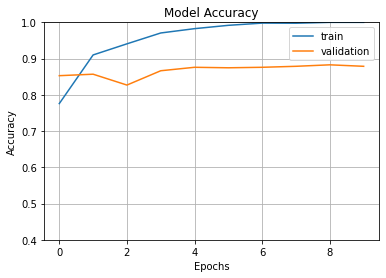

In [ ]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

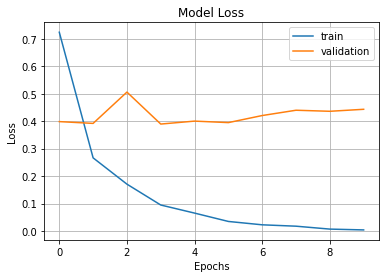

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

# Making Predictions

In [ ]:
import cv2
image=cv2.imread(str(roses[0]))
image_resized= cv2.resize(image, (img_height,img_width))
image=np.expand_dims(image_resized,axis=0)
print(image.shape)


(1, 180, 180, 3)


In [45]:
pred=resnet_model.predict(image)
print(pred)

[[8.2068445e-06 1.5209365e-06 9.9347222e-01 9.5006551e-05 6.4231041e-03]]


In [ ]:
output_class=class_names[np.argmax(pred)]
print("The predicted class is", output_class)

The predicted class is roses
